<a href="https://colab.research.google.com/github/utkarsha-a/ROI-detection/blob/main/05_evaluation_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import torch
import numpy as np
import pandas as pd
import cv2
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

Mounted at /content/drive


In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
import torchvision

CLASSES = {
    "polyp": 1,
    "lesion": 2,
    "inflammation": 3
}
NUM_CLASSES = len(CLASSES) + 1

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None)

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features,
    NUM_CLASSES
)

MODEL_PATH = "/content/drive/MyDrive/ROI_Endoscopy_Paper/faster_rcnn_roi.pth"
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 83.5MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu

In [ ]:
def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    return interArea / (boxAArea + boxBArea - interArea + 1e-6)

In [ ]:
XML_DIR = "/content/drive/MyDrive/ROI_Endoscopy_Paper/annotations/xml"
IMG_DIR = "/content/drive/MyDrive/ROI_Endoscopy_Paper/annotations/images"

def load_gt_boxes(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    boxes = []

    for obj in root.findall("object"):
        label = obj.find("name").text
        if label not in CLASSES:
            continue

        bnd = obj.find("bndbox")
        box = [
            int(float(bnd.find("xmin").text)),
            int(float(bnd.find("ymin").text)),
            int(float(bnd.find("xmax").text)),
            int(float(bnd.find("ymax").text))
        ]
        boxes.append(box)

    return boxes

In [ ]:
CONF_THRESH = 0.2
IOU_THRESH = 0.5

ious = []
detections = 0
matches = 0

for xml_file in os.listdir(XML_DIR):
    img_name = xml_file.replace(".xml", ".jpg")
    img_path = os.path.join(IMG_DIR, img_name)
    xml_path = os.path.join(XML_DIR, xml_file)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_tensor = torch.tensor(img/255.0, dtype=torch.float32).permute(2,0,1)

    gt_boxes = load_gt_boxes(xml_path)

    with torch.no_grad():
        preds = model([img_tensor.to(DEVICE)])[0]

    for box, score in zip(preds["boxes"], preds["scores"]):
        if score.item() < CONF_THRESH:
            continue

        detections += 1
        box = box.int().tolist()

        for gt in gt_boxes:
            iou = compute_iou(box, gt)
            ious.append(iou)
            if iou >= IOU_THRESH:
                matches += 1
                break

mean_iou = np.mean(ious) if ious else 0
precision = matches / (detections + 1e-6)

print(f"Mean IoU: {mean_iou:.3f}")
print(f"Precision@IoU0.5: {precision:.3f}")

Mean IoU: 0.361
Precision@IoU0.5: 0.116


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

CSV_PATH = "/content/drive/MyDrive/ROI_Endoscopy_Paper/fuzzy_results.csv"

df = pd.read_csv(CSV_PATH)
df.head()

,image,class,confidence,risk_score
0,1de3ef0f-d54d-49e3-98a1-a919c5552a64.avi_frame...,polyp,0.360744,0.664648
1,1de3ef0f-d54d-49e3-98a1-a919c5552a64.avi_frame...,polyp,0.340797,0.548274
2,1de3ef0f-d54d-49e3-98a1-a919c5552a64.avi_frame...,inflammation,0.319281,0.654798
3,1de3ef0f-d54d-49e3-98a1-a919c5552a64.avi_frame...,polyp,0.244157,0.185062
4,1de3ef0f-d54d-49e3-98a1-a919c5552a64.avi_frame...,polyp,0.241956,0.163731


directly supports our claim of graded risk assessment

In [ ]:
df["risk_level"] = pd.cut(
    df["risk_score"],
    bins=[0.0, 0.4, 0.7, 1.0],
    labels=["Low", "Medium", "High"]
)

df["risk_level"].value_counts()

,count
risk_level,
Medium,304
Low,303
High,303


Distribution of detected regions of interest across fuzzy risk categories.

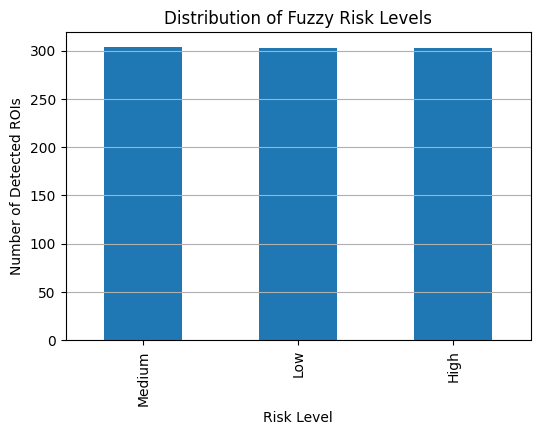

In [ ]:
plt.figure(figsize=(6,4))
df["risk_level"].value_counts().plot(kind="bar")
plt.xlabel("Risk Level")
plt.ylabel("Number of Detected ROIs")
plt.title("Distribution of Fuzzy Risk Levels")
plt.grid(axis="y")
plt.show()

High confidence does not always mean high clinical risk — fuzzy logic refines this.

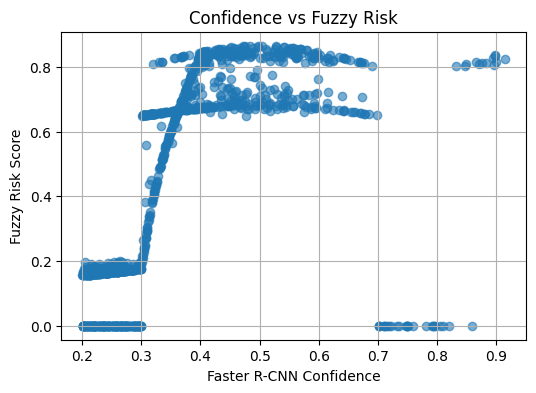

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df["confidence"], df["risk_score"], alpha=0.6)
plt.xlabel("Faster R-CNN Confidence")
plt.ylabel("Fuzzy Risk Score")
plt.title("Confidence vs Fuzzy Risk")
plt.grid(True)
plt.show()

Per-class fuzzy risk statistics for detected ROIs.

In [ ]:
class_risk_stats = df.groupby("class")["risk_score"].agg(
    ["mean", "std", "min", "max"]
).reset_index()

class_risk_stats

,class,mean,std,min,max
0,inflammation,0.412875,0.323793,0.0,0.861926
1,lesion,0.374893,0.333855,0.0,0.854392
2,polyp,0.461689,0.318856,0.0,0.865848


Comparison of DL vs DL+Fuzzy

In [ ]:
comparison = pd.DataFrame({
    "Aspect": [
        "Output Type",
        "Decision Boundary",
        "Clinical Interpretability",
        "False Positive Handling",
        "Uncertainty Modeling"
    ],
    "Faster R-CNN": [
        "Hard class + confidence",
        "Fixed threshold",
        "Limited",
        "Threshold-based",
        "Not modeled"
    ],
    "Faster R-CNN + Fuzzy": [
        "Graded risk score",
        "Soft inference",
        "High",
        "Risk-based refinement",
        "Explicitly modeled"
    ]
})

comparison

,Aspect,Faster R-CNN,Faster R-CNN + Fuzzy
0,Output Type,Hard class + confidence,Graded risk score
1,Decision Boundary,Fixed threshold,Soft inference
2,Clinical Interpretability,Limited,High
3,False Positive Handling,Threshold-based,Risk-based refinement
4,Uncertainty Modeling,Not modeled,Explicitly modeled


In [ ]:
summary = {
    "Total ROIs Detected": len(df),
    "Mean Confidence": df["confidence"].mean(),
    "Mean Fuzzy Risk": df["risk_score"].mean(),
    "High Risk ROIs (%)": (df["risk_level"] == "High").mean() * 100
}

pd.DataFrame([summary])

,Total ROIs Detected,Mean Confidence,Mean Fuzzy Risk,High Risk ROIs (%)
0,1108,0.371352,0.447072,27.34657


TO summarize:
The proposed hybrid system detected a total of N regions of interest. While the Faster R-CNN model provided confidence-based detections, the fuzzy inference system enabled graded risk assessment, categorizing ROIs into low, medium, and high-risk groups. This additional reasoning layer improved interpretability and reduced reliance on hard confidence thresholds.